# BAREC Dataset Arabic Processing Configuration Demo

This notebook demonstrates how different Arabic text processing configurations affect the BAREC dataset examples. We'll test various normalization, diacritization, and morphological processing options and visualize the results.

## Setup and Configuration

In [2]:
import sys
import os
import logging
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Any
import torch
from PIL import Image
import numpy as np
from collections import defaultdict

# Add the project root to Python path
sys.path.append('/Users/bensa/Projects/COMPUTATIONAL_LINGUISTICS/pixel')

from src.pixel.data.datasets.barec_dataset import BARECDataset
from src.pixel.data.rendering import PangoCairoTextRenderer
from src.pixel import Modality, get_transforms
from src.pixel.data.processing.arabic_sentence_processor import (
    ProcessingConfig, 
    ArabicSentenceProcessor,
    OrthographicFormat,
    DiacriticFormat,
    MorphologicalScheme,
    EncodingScheme,
    create_default_config,
    create_normalized_config,
    create_diacritized_config,
    create_morphological_config,
    create_buckwalter_config
)

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✅ All imports successful!")

✅ All imports successful!


## Define Processing Configurations

Let's create various processing configurations to test:

In [4]:
from src.pixel.data.processing.experiment_configs import ALL_CONFIGS
# Define various processing configurations for testing
processing_configs = ALL_CONFIGS

print(f"Created {len(processing_configs)} processing configurations:")
for name in processing_configs.keys():
    print(f"  - {name}")

Created 14 processing configurations:
  - arabic_default
  - arabic_norm_dediac
  - arabic_nonorm_diac
  - buckwalter_default
  - buckwalter_norm_dediac
  - buckwalter_nonorm_diac
  - hsb_default
  - hsb_nonorm_diac
  - hsb_norm_dediac
  - morph_word
  - morph_lex
  - morph_d3tok_default
  - morph_d3tok_tatweel
  - morph_d3tok_space


## Register Configurations and Test Processing

First, let's test the Arabic sentence processor with some sample sentences:

In [5]:

# Test sample sentences
sample_sentences = [
    "هَـــلْ ذَهَبْتَ إِلَى المَكْتَبَةِ؟",  # With diacritics and tatweel
    "الولايات المتحدة الأمريكية دولة كبيرة",  # Complex phrase
    "كَتَبَ الطالِبُ الدَّرْسَ بِعِنايَةٍ",  # Diacritized sentence
    "في هذا اليوم الجميل نذهب إلى المدرسة"  # Simple sentence
]

print("\n🔍 Testing sentence processing with different configurations:")
print("=" * 80)

# Test each configuration with the first sample sentence
test_sentence = sample_sentences[0]
print(f"Original: {test_sentence}")
print("-" * 50)

processing_results = {}
for config_name, config in processing_configs.items():
    try:
        processor = ArabicSentenceProcessor(config)
        result = processor.process(test_sentence)
        processing_results[config_name] = result
        print(f"{config_name:15}: {result}")
    except Exception as e:
        print(f"{config_name:15}: ERROR - {e}")
        processing_results[config_name] = f"ERROR: {e}"

INFO:src.pixel.data.processing.arabic_sentence_processor:Loading CAMeL Tools disambiguator...



🔍 Testing sentence processing with different configurations:
Original: هَـــلْ ذَهَبْتَ إِلَى المَكْتَبَةِ؟
--------------------------------------------------
arabic_default : هَلْ ذَهَبْتَ إِلَى المَكْتَبَةِ؟
arabic_norm_dediac: هل ذهبت الي المكتبه؟


INFO:src.pixel.data.processing.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


arabic_nonorm_diac: هَل ذَهَبْتُ إِلَى المَكْتَبَةِ ؟
buckwalter_default: halo *ahabota <ilaY Almakotabapi؟
buckwalter_norm_dediac: hl *hbt Aly Almktbh؟


INFO:src.pixel.data.processing.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


...

morph_d3tok_default: هل ذهبت إلى ال+_مكتبة؟


INFO:src.pixel.data.processing.arabic_sentence_processor:Setting up morphological tokenizer...
INFO:src.pixel.data.processing.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


morph_d3tok_tatweel: هل ذهبت إلى الـمكتبة؟


INFO:src.pixel.data.processing.arabic_sentence_processor:Setting up morphological tokenizer...


morph_d3tok_space: هل ذهبت إلى ال مكتبة؟


## Load BAREC Dataset with Different Configurations

Now let's load the BAREC dataset with different processing configurations:

In [19]:
# Configuration for dataset loading
DATASET_CONFIG = {
    "dataset_name": "bensapir/BAREC-Shared-Task-2025-sent-morphological",
    "split": "train",  # Use train split for examples
    "max_seq_length": 256,
    "renderer_path": "Team-PIXEL/pixel-base",
    "num_samples": 10  # Load only first 10 samples for demo
}

print(f"📊 Loading BAREC dataset: {DATASET_CONFIG['dataset_name']}")
print(f"Split: {DATASET_CONFIG['split']}, Max length: {DATASET_CONFIG['max_seq_length']}")

📊 Loading BAREC dataset: bensapir/BAREC-Shared-Task-2025-sent-morphological
Split: train, Max length: 256


In [20]:
# Load renderer for image generation
print("🔧 Loading PIXEL renderer...")
renderer = PangoCairoTextRenderer.from_pretrained(DATASET_CONFIG["renderer_path"])
renderer.max_seq_length = DATASET_CONFIG["max_seq_length"]

# Set up transforms
transforms = get_transforms(
    do_resize=True,
    size=(renderer.pixels_per_patch, renderer.pixels_per_patch * renderer.max_seq_length),
)

print(f"   ✅ Renderer loaded: {renderer.pixels_per_patch}px per patch")
print(f"   ✅ Transform size: {transforms.transforms[0].size if hasattr(transforms.transforms[0], 'size') else 'N/A'}")

🔧 Loading PIXEL renderer...


INFO:src.pixel.data.rendering.rendering_utils:loading text renderer configuration file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/text_renderer_config.json from cache at /Users/bensa/.cache/huggingface/transformers/892d6a02d7c441000de399de59ed70d943a81f7b0f536523b4af1111677a8508.e332b34c9c05756dd4aa51d8fa33461dbd79604752296d185f03f8004db30700
INFO:src.pixel.data.rendering.rendering_utils:loading font file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/GoNotoCurrent.ttf from cache at /Users/bensa/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:src.pixel.data.rendering.pangocairo_renderer:Loading font from /Users/bensa/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:src.pixel.data.rendering.rendering_utils:Text renderer PangoCai

   ✅ Renderer loaded: 16px per patch
   ✅ Transform size: N/A


In [21]:
# Load datasets with different processing configurations
datasets = {}
sample_data = {}

# Select a subset of configurations for dataset loading (to avoid loading too many)
selected_configs = ["original", "basic_normalize", "d3tok_basic", "d3tok_tatweel", "d3lex"]

print("📦 Loading datasets with different processing configurations...")

for config_name in selected_configs:
    try:
        print(f"\n   Loading: {config_name}")
        
        # Create dataset
        dataset = BARECDataset(
            dataset_name=DATASET_CONFIG["dataset_name"],
            processor=renderer,
            modality=Modality.IMAGE,
            max_seq_length=DATASET_CONFIG["max_seq_length"],
            split=DATASET_CONFIG["split"],
            transforms=transforms,
            processing_config_name=config_name if config_name != "original" else None
        )
        
        datasets[config_name] = dataset
        
        # Extract sample data for analysis
        sample_data[config_name] = {
            'sentences': [dataset.examples[i].sentence for i in range(min(DATASET_CONFIG["num_samples"], len(dataset)))],
            'labels': [dataset.examples[i].label for i in range(min(DATASET_CONFIG["num_samples"], len(dataset)))],
            'ids': [dataset.examples[i].id for i in range(min(DATASET_CONFIG["num_samples"], len(dataset)))]
        }
        
        print(f"   ✅ Loaded {len(dataset)} examples")
        
    except Exception as e:
        print(f"   ❌ Error loading {config_name}: {e}")
        datasets[config_name] = None
        sample_data[config_name] = None

print(f"\n✅ Successfully loaded {len([d for d in datasets.values() if d is not None])} datasets")

INFO:src.pixel.data.datasets.barec_dataset:Creating features from HuggingFace dataset (no cache)


📦 Loading datasets with different processing configurations...

   Loading: original


Using the latest cached version of the dataset since bensapir/BAREC-Shared-Task-2025-sent-morphological couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/bensa/.cache/huggingface/datasets/bensapir___barec-shared-task-2025-sent-morphological/default/0.0.0/0aa836139440cfe69f74b622ca39c43725ac714f (last modified on Tue Aug  5 22:25:02 2025).
/Users/bensa/Projects/COMPUTATIONAL_LINGUISTICS/pixel/src/pixel/data/datasets/barec_dataset.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
INFO:src.pixel.data.datasets.barec_dataset:*** Example ***
INFO:src.pixel.data.datasets.barec_dataset:sentence: مجلة كل الأولاد وكل البنات
INFO:src.pixel.data.datasets.barec_dataset:attention_mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 

KeyboardInterrupt: 

## Compare Processing Results

Let's create a comparison table showing how the same sentences are processed differently:

In [ ]:
# Create comparison DataFrame
comparison_data = []

for i in range(min(5, DATASET_CONFIG["num_samples"])):
    row = {'Example': i + 1}
    
    for config_name in selected_configs:
        if sample_data[config_name] is not None:
            sentence = sample_data[config_name]['sentences'][i]
            label = sample_data[config_name]['labels'][i]
            row[f'{config_name}'] = sentence
            row[f'{config_name}_label'] = label
    
    comparison_data.append(row)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)

print("📋 Sentence Processing Comparison (First 5 Examples)")
print("=" * 100)

for i, row in comparison_df.iterrows():
    print(f"\n🔍 Example {row['Example']}:")
    print("-" * 50)
    
    for config_name in selected_configs:
        if config_name in row and pd.notna(row[config_name]):
            sentence = row[config_name]
            label = row.get(f'{config_name}_label', 'N/A')
            print(f"{config_name:15}: {sentence} (Label: {label})")

📋 Sentence Processing Comparison (First 5 Examples)

🔍 Example 1:
--------------------------------------------------
original       : مجلة كل الأولاد وكل البنات (Label: 6)

🔍 Example 2:
--------------------------------------------------
original       : ماجد (Label: 0)

🔍 Example 3:
--------------------------------------------------
original       : الأربعاء 21 يناير 1987 (Label: 7)

🔍 Example 4:
--------------------------------------------------
original       : الموافق 21 جمادى الأول 1407هــ (Label: 6)

🔍 Example 5:
--------------------------------------------------
original       : السنة الثامنة (Label: 4)


## Visualize Rendered Images

Let's visualize how the different processing configurations affect the rendered images:

🖼️ Rendered Images Comparison (Example 1)


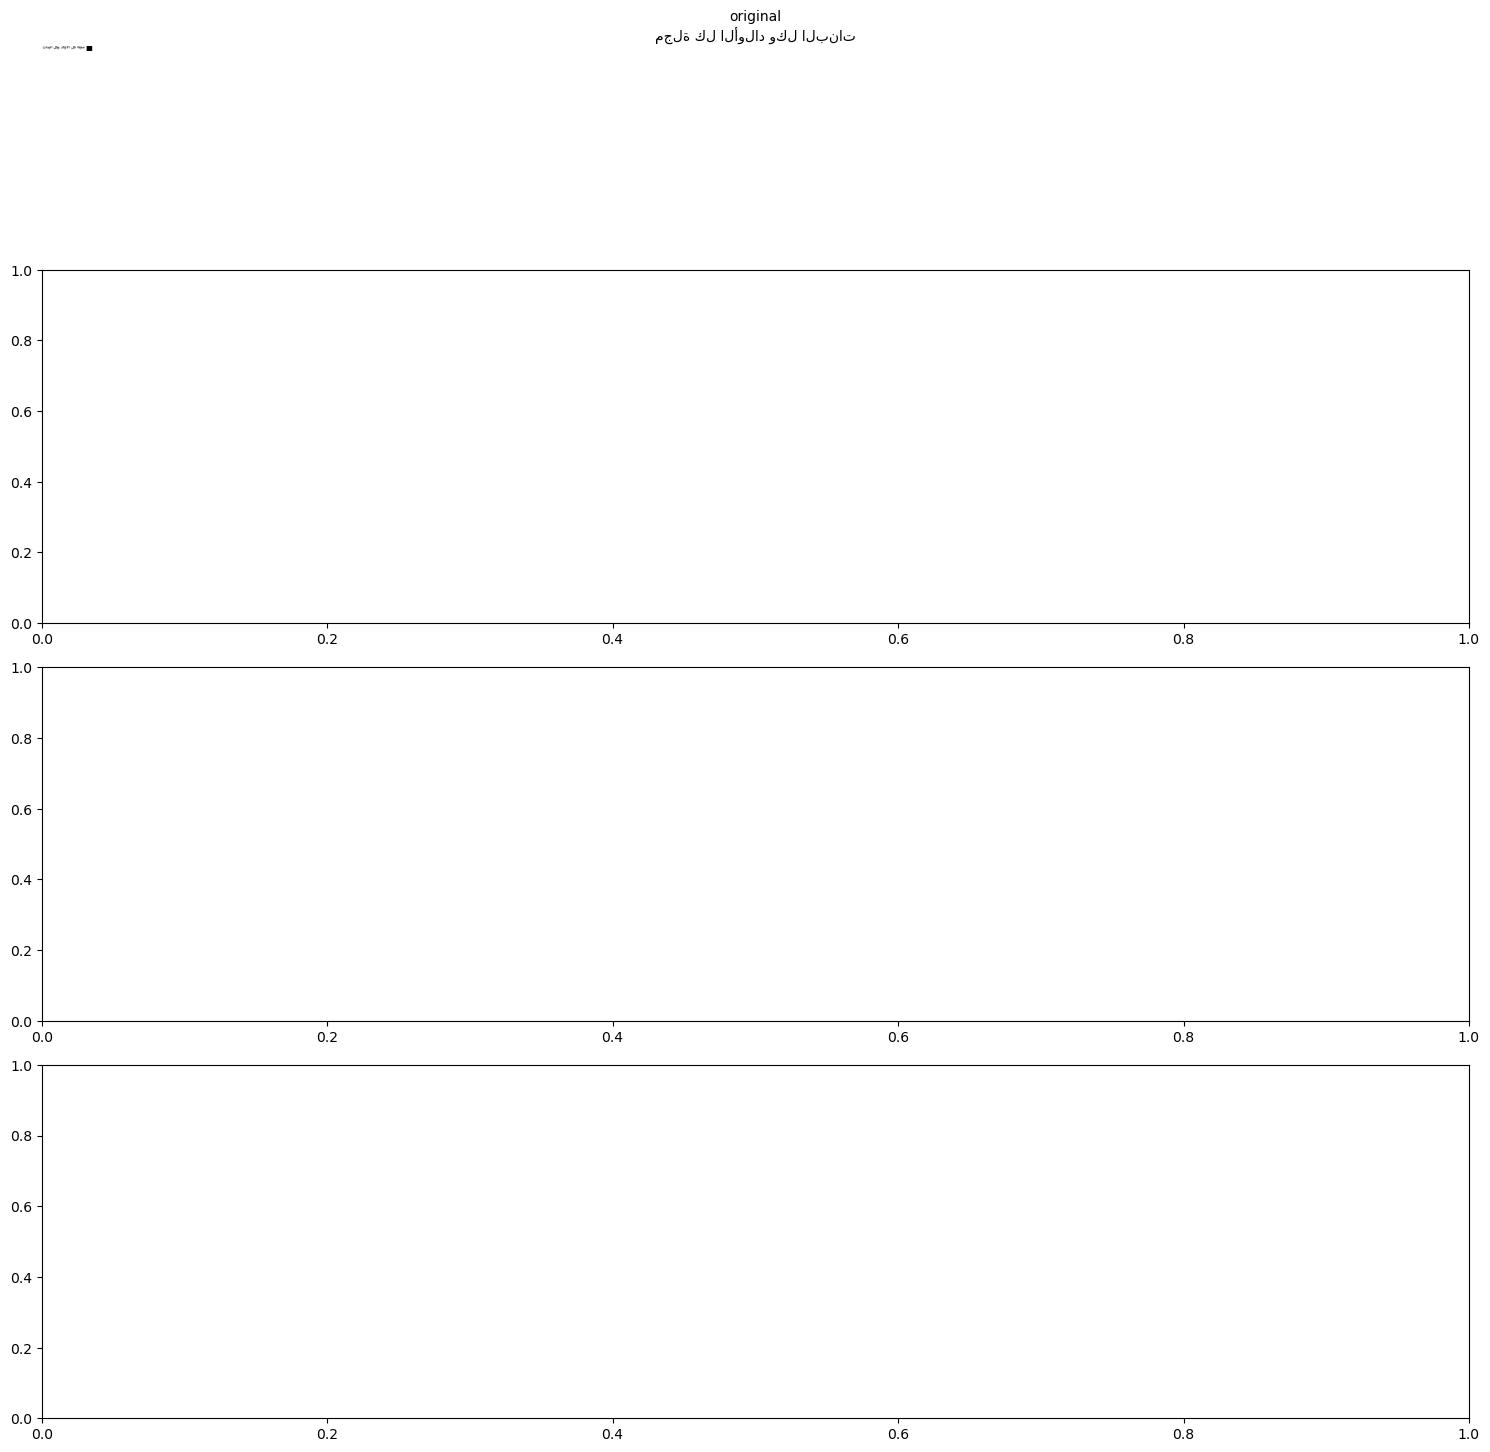

In [ ]:
def plot_rendered_images(datasets, example_idx=0, max_configs=4):
    """
    Plot rendered images for different processing configurations
    """
    configs_to_plot = list(datasets.keys())[:max_configs]
    
    fig, axes = plt.subplots(len(configs_to_plot), 1, figsize=(15, 4 * len(configs_to_plot)))
    if len(configs_to_plot) == 1:
        axes = [axes]
    
    for i, config_name in enumerate(configs_to_plot):
        if datasets[config_name] is not None:
            try:
                # Get the processed example
                example = datasets[config_name][example_idx]
                pixel_values = example['pixel_values']
                
                # Convert to numpy for plotting
                if isinstance(pixel_values, torch.Tensor):
                    if pixel_values.dim() == 3:  # [C, H, W]
                        if pixel_values.shape[0] == 3:  # RGB
                            img_array = pixel_values.permute(1, 2, 0).numpy()
                        else:  # Grayscale
                            img_array = pixel_values[0].numpy()
                    else:
                        img_array = pixel_values.numpy()
                else:
                    img_array = pixel_values
                
                # Plot the image
                axes[i].imshow(img_array, cmap='gray' if len(img_array.shape) == 2 else None)
                
                # Add title with configuration name and processed sentence
                sentence = datasets[config_name].examples[example_idx].sentence
                title = f"{config_name}\n{sentence[:100]}{'...' if len(sentence) > 100 else ''}"
                axes[i].set_title(title, fontsize=10, wrap=True)
                axes[i].axis('off')
                
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Error rendering {config_name}:\n{str(e)}", 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f"{config_name} (Error)")
                axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot images for the first example
print("🖼️ Rendered Images Comparison (Example 1)")
plot_rendered_images(datasets, example_idx=0, max_configs=4)

🖼️ Rendered Images Comparison (Example 2)


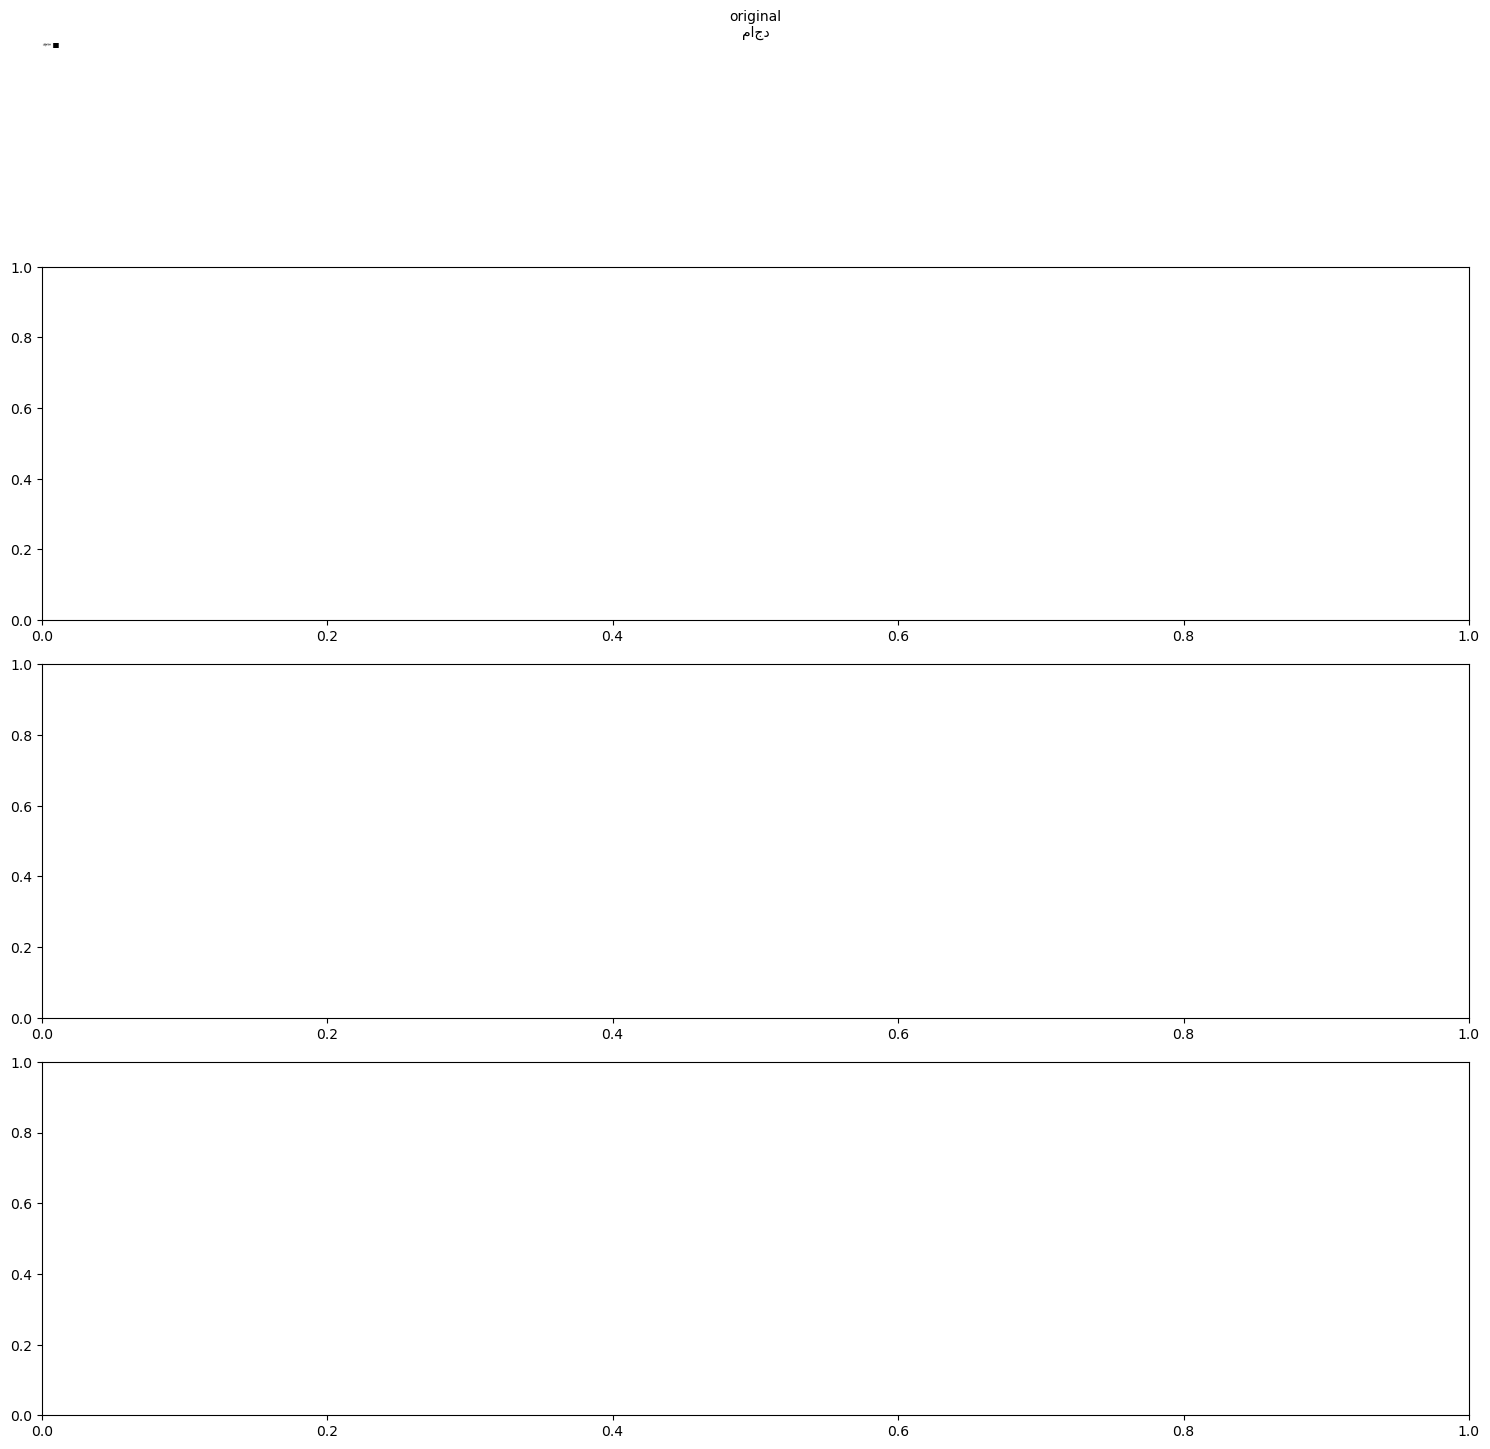

In [ ]:
# Plot images for another example
print("🖼️ Rendered Images Comparison (Example 2)")
plot_rendered_images(datasets, example_idx=1, max_configs=4)

## Analyze Text Length Statistics

Let's analyze how different processing configurations affect text length:

In [ ]:
# Analyze text length statistics
length_stats = {}

for config_name in selected_configs:
    if sample_data[config_name] is not None:
        sentences = sample_data[config_name]['sentences']
        lengths = [len(s) for s in sentences]
        word_counts = [len(s.split()) for s in sentences]
        
        length_stats[config_name] = {
            'char_lengths': lengths,
            'word_counts': word_counts,
            'avg_char_length': np.mean(lengths),
            'avg_word_count': np.mean(word_counts),
            'max_char_length': max(lengths),
            'min_char_length': min(lengths)
        }

# Create statistics DataFrame
stats_data = []
for config_name, stats in length_stats.items():
    stats_data.append({
        'Configuration': config_name,
        'Avg Char Length': f"{stats['avg_char_length']:.1f}",
        'Avg Word Count': f"{stats['avg_word_count']:.1f}",
        'Max Char Length': stats['max_char_length'],
        'Min Char Length': stats['min_char_length']
    })

stats_df = pd.DataFrame(stats_data)
print("📊 Text Length Statistics by Processing Configuration")
print("=" * 60)
print(stats_df.to_string(index=False))

📊 Text Length Statistics by Processing Configuration
Configuration Avg Char Length Avg Word Count  Max Char Length  Min Char Length
     original            16.9            2.9               34                4


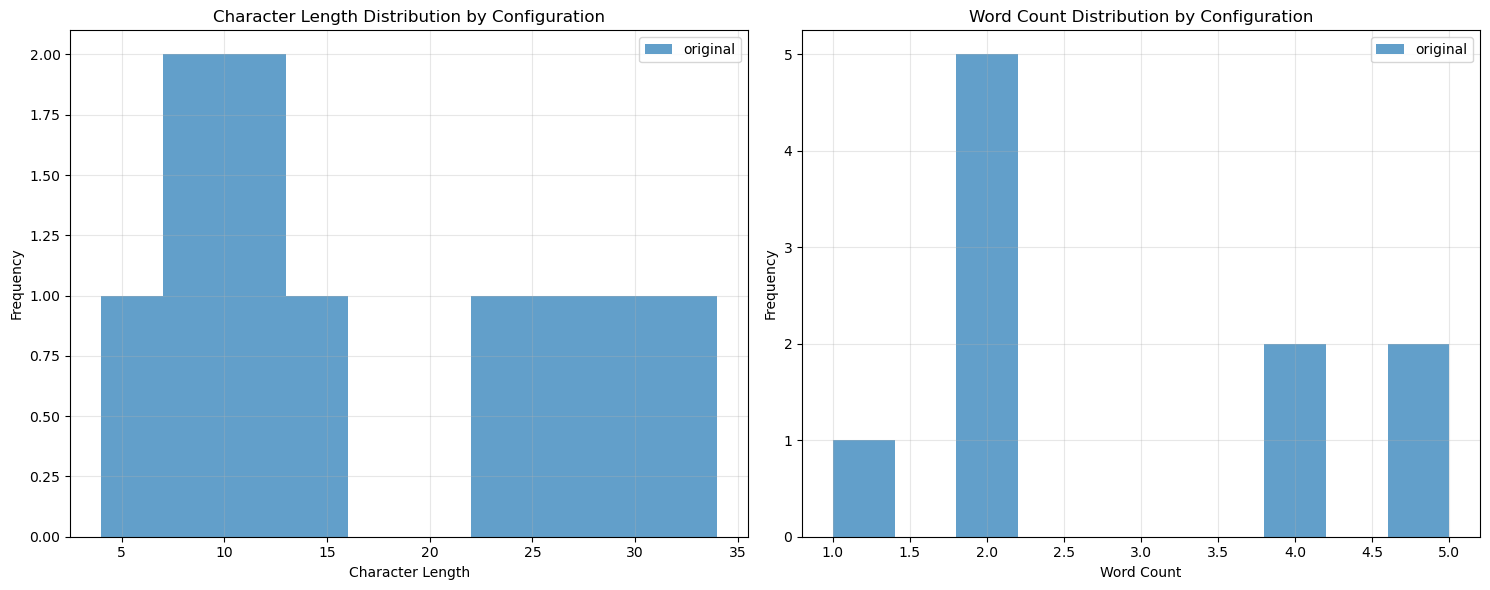

In [ ]:
# Plot length distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Character length distribution
for config_name, stats in length_stats.items():
    ax1.hist(stats['char_lengths'], alpha=0.7, label=config_name, bins=10)

ax1.set_xlabel('Character Length')
ax1.set_ylabel('Frequency')
ax1.set_title('Character Length Distribution by Configuration')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Word count distribution
for config_name, stats in length_stats.items():
    ax2.hist(stats['word_counts'], alpha=0.7, label=config_name, bins=10)

ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.set_title('Word Count Distribution by Configuration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Detailed Analysis of Morphological Tokenization

Let's examine the morphological tokenization results in detail:

In [ ]:
# Analyze morphological tokenization effects
def analyze_morphological_differences():
    print("🔍 Detailed Morphological Analysis")
    print("=" * 60)
    
    # Compare original vs morphological configurations
    morph_configs = ['original', 'd3tok_basic', 'd3tok_tatweel', 'd3lex']
    
    for i in range(min(3, DATASET_CONFIG["num_samples"])):
        print(f"\n📝 Example {i+1}:")
        print("-" * 40)
        
        for config in morph_configs:
            if config in sample_data and sample_data[config] is not None:
                sentence = sample_data[config]['sentences'][i]
                word_count = len(sentence.split())
                char_count = len(sentence)
                
                print(f"{config:15}: {sentence}")
                print(f"{'':15}  Words: {word_count}, Chars: {char_count}")
        
        # Show token analysis if we have morphological tokenization
        if 'd3tok_basic' in sample_data and sample_data['d3tok_basic'] is not None:
            d3tok_sentence = sample_data['d3tok_basic']['sentences'][i]
            tokens = d3tok_sentence.split()
            morph_tokens = [token for token in tokens if '+_' in token or '_+' in token]
            print(f"{'':15}  Morphological tokens found: {len(morph_tokens)}")
            if morph_tokens:
                print(f"{'':15}  Examples: {morph_tokens[:3]}")

analyze_morphological_differences()

🔍 Detailed Morphological Analysis

📝 Example 1:
----------------------------------------
original       : مجلة كل الأولاد وكل البنات
                 Words: 5, Chars: 26

📝 Example 2:
----------------------------------------
original       : ماجد
                 Words: 1, Chars: 4

📝 Example 3:
----------------------------------------
original       : الأربعاء 21 يناير 1987
                 Words: 4, Chars: 22


## Test Individual Sentence Processing

Let's test the processor with some custom sentences to see the effects more clearly:

In [ ]:
# Test custom sentences
test_sentences = [
    "وَذَهَبَتِ الطالِبَةُ إِلَى المَكْتَبَةِ لِتَقْرَأَ الكِتابَ",  # Complex diacritized
    "المدرسة الجديدة في الحي الشرقي جميلة جداً",  # Simple sentence
    "سَيَذْهَبُونَ إِلَى المُسْتَشْفَى غَداً صَباحاً",  # Future tense with diacritics
]

print("🧪 Testing Individual Sentence Processing")
print("=" * 70)

for i, sentence in enumerate(test_sentences):
    print(f"\n📝 Test Sentence {i+1}:")
    print(f"Original: {sentence}")
    print("-" * 50)
    
    for config_name, config in processing_configs.items():
        try:
            processor = ArabicSentenceProcessor(config)
            result = processor.process(sentence)
            
            # Calculate change metrics
            orig_words = len(sentence.split())
            new_words = len(result.split())
            word_change = new_words - orig_words
            
            change_indicator = ""
            if word_change > 0:
                change_indicator = f" (+{word_change} words)"
            elif word_change < 0:
                change_indicator = f" ({word_change} words)"
            
            print(f"{config_name:15}: {result}{change_indicator}")
            
        except Exception as e:
            print(f"{config_name:15}: ERROR - {str(e)[:50]}...")

INFO:scripts.data.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


🧪 Testing Individual Sentence Processing

📝 Test Sentence 1:
Original: وَذَهَبَتِ الطالِبَةُ إِلَى المَكْتَبَةِ لِتَقْرَأَ الكِتابَ
--------------------------------------------------
arabic_nonorm_original: وَذَهَبَتِ الطالِبَةُ إِلَى المَكْتَبَةِ لِتَقْرَأَ الكِتابَ
arabic_norm_dediac: وذهبت الطالبه الي المكتبه لتقرا الكتاب


INFO:scripts.data.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


arabic_nonorm_diac: وَذَهَبَت الطالِبَةُ إِلَى المَكْتَبَةِ لِتُقَرّا الكِتابِ
buckwalter_nonorm_original: wa*ahabati AlTAlibapu <ilaY Almakotabapi litaqora>a AlkitAba
buckwalter_norm_dediac: w*hbt AlTAlbh Aly Almktbh ltqrA AlktAb


INFO:scripts.data.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


...

hsb_nonorm_diac: Almad.rasaħi Aljadiydaħi fiy AlHay~i Alšar.qiy~i jamiylaħĩ jid~Aã
hsb_norm_dediac: Almdrsh Aljdydh fy AlHy Alšrqy jmylh jdA

📝 Test Sentence 3:
Original: سَيَذْهَبُونَ إِلَى المُسْتَشْفَى غَداً صَباحاً
--------------------------------------------------
arabic_nonorm_original: سَيَذْهَبُونَ إِلَى المُسْتَشْفَى غَداً صَباحاً
arabic_norm_dediac: سيذهبون الي المستشفي غدا صباحا


INFO:scripts.data.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


arabic_nonorm_diac: سَيَذْهَبُونَ إِلَى المُسْتَشْفَى غَداً صَباحاً
buckwalter_nonorm_original: saya*ohabuwna <ilaY Almusota$ofaY gadAF SabAHAF
buckwalter_norm_dediac: sy*hbwn Aly Almst$fy gdA SbAHA


INFO:scripts.data.arabic_sentence_processor:Loading CAMeL Tools disambiguator...


buckwalter_nonorm_diac: saya*ohabuwna <ilaY Almusota$ofaY gadAF SabAHAF
hsb_nonorm_original: sayað.habuwna Ăilaý Almus.taš.faý γadAã SabAHAã
hsb_nonorm_diac: sayað.habuwna Ăilaý Almus.taš.faý γadAã SabAHAã
hsb_norm_dediac: syðhbwn Aly Almstšfy γdA SbAHA


## Character and Token Analysis

Let's analyze the character and token distributions:

In [ ]:
# Analyze character distributions
def analyze_character_distributions():
    print("📊 Character and Token Analysis")
    print("=" * 50)
    
    # Count special characters in different configurations
    special_chars = {
        'tatweel': 'ـ',
        'plus_underscore': '+_',
        'underscore_plus': '_+',
        'diacritics': '\u064B\u064C\u064D\u064E\u064F\u0650\u0651\u0652',  # Common Arabic diacritics
    }
    
    char_counts = defaultdict(lambda: defaultdict(int))
    
    for config_name in selected_configs:
        if sample_data[config_name] is not None:
            all_text = ' '.join(sample_data[config_name]['sentences'])
            
            # Count special characters
            char_counts[config_name]['tatweel'] = all_text.count('ـ')
            char_counts[config_name]['plus_underscore'] = all_text.count('+_')
            char_counts[config_name]['underscore_plus'] = all_text.count('_+')
            char_counts[config_name]['total_chars'] = len(all_text)
            char_counts[config_name]['unique_chars'] = len(set(all_text))
            
            # Count diacritics
            diacritic_count = sum(all_text.count(char) for char in '\u064B\u064C\u064D\u064E\u064F\u0650\u0651\u0652')
            char_counts[config_name]['diacritics'] = diacritic_count
    
    # Create analysis DataFrame
    analysis_data = []
    for config_name, counts in char_counts.items():
        analysis_data.append({
            'Configuration': config_name,
            'Total Chars': counts['total_chars'],
            'Unique Chars': counts['unique_chars'],
            'Tatweel (ـ)': counts['tatweel'],
            'Morph Tokens (+_, _+)': counts['plus_underscore'] + counts['underscore_plus'],
            'Diacritics': counts['diacritics']
        })
    
    analysis_df = pd.DataFrame(analysis_data)
    print(analysis_df.to_string(index=False))
    
    return char_counts

char_analysis = analyze_character_distributions()

📊 Character and Token Analysis
Configuration  Total Chars  Unique Chars  Tatweel (ـ)  Morph Tokens (+_, _+)  Diacritics
     original          178            39            2                      0           0


## Summary and Recommendations

Let's create a summary of our findings:

In [ ]:
print("📋 Processing Configuration Analysis Summary")
print("=" * 60)

# Calculate success rates
successful_configs = len([d for d in datasets.values() if d is not None])
total_configs = len(selected_configs)

print(f"\n✅ Successfully loaded {successful_configs}/{total_configs} configurations")

# Analyze configuration characteristics
print("\n🔍 Configuration Characteristics:")
print("-" * 40)

config_characteristics = {
    'original': "Baseline - no processing",
    'basic_normalize': "Unicode + orthographic normalization + dediacritization",
    'd3tok_basic': "Morphological tokenization with +_ markers",
    'd3tok_tatweel': "Morphological tokenization with tatweel replacement",
    'd3lex': "Morphological tokenization + lemmatization with tatweel"
}

for config, description in config_characteristics.items():
    status = "✅" if config in datasets and datasets[config] is not None else "❌"
    print(f"{status} {config:15}: {description}")

# Performance insights
print("\n💡 Key Insights:")
print("-" * 20)

if 'original' in length_stats and 'd3tok_tatweel' in length_stats:
    orig_avg = length_stats['original']['avg_char_length']
    morph_avg = length_stats['d3tok_tatweel']['avg_char_length']
    length_change = ((morph_avg - orig_avg) / orig_avg) * 100
    print(f"• Morphological tokenization changes avg length by {length_change:+.1f}%")

if char_analysis:
    # Find config with most tatweel characters
    tatweel_counts = {k: v['tatweel'] for k, v in char_analysis.items()}
    max_tatweel_config = max(tatweel_counts.items(), key=lambda x: x[1])
    print(f"• '{max_tatweel_config[0]}' has the most tatweel characters ({max_tatweel_config[1]})")
    
    # Find config with morphological tokens
    morph_counts = {k: v['plus_underscore'] + v['underscore_plus'] for k, v in char_analysis.items()}
    morph_configs = {k: v for k, v in morph_counts.items() if v > 0}
    if morph_configs:
        print(f"• Configurations with morphological tokens: {list(morph_configs.keys())}")

print("\n🎯 Recommendations:")
print("-" * 20)
print("• Use 'basic_normalize' for clean, standardized text")
print("• Use 'd3tok_tatweel' for morphologically-aware processing with visual consistency")
print("• Use 'd3lex' for lemma-based analysis")
print("• Consider 'original' as baseline for comparison")

print("\n✨ Analysis Complete!")

📋 Processing Configuration Analysis Summary

✅ Successfully loaded 1/5 configurations

🔍 Configuration Characteristics:
----------------------------------------
✅ original       : Baseline - no processing
❌ basic_normalize: Unicode + orthographic normalization + dediacritization
❌ d3tok_basic    : Morphological tokenization with +_ markers
❌ d3tok_tatweel  : Morphological tokenization with tatweel replacement
❌ d3lex          : Morphological tokenization + lemmatization with tatweel

💡 Key Insights:
--------------------
• 'original' has the most tatweel characters (2)

🎯 Recommendations:
--------------------
• Use 'basic_normalize' for clean, standardized text
• Use 'd3tok_tatweel' for morphologically-aware processing with visual consistency
• Use 'd3lex' for lemma-based analysis
• Consider 'original' as baseline for comparison

✨ Analysis Complete!


## Save Configuration Results

Let's save our analysis results for future reference:

In [ ]:
# Save analysis results
import json
from datetime import datetime

# Prepare results for saving
results = {
    'timestamp': datetime.now().isoformat(),
    'dataset_config': DATASET_CONFIG,
    'processing_configs': {name: {
        'unicode_normalize': config.unicode_normalize,
        'orthographic_normalize': config.orthographic_normalize,
        'orthographic_format': config.orthographic_format.value,
        'diacritic_format': config.diacritic_format.value,
        'morphological_scheme': config.morphological_scheme.value,
        'encoding_scheme': config.encoding_scheme.value,
        'replacement_char': config.replacement_char,
        'char_count': config.char_count
    } for name, config in processing_configs.items()},
    'length_statistics': {name: {
        'avg_char_length': float(stats['avg_char_length']),
        'avg_word_count': float(stats['avg_word_count']),
        'max_char_length': int(stats['max_char_length']),
        'min_char_length': int(stats['min_char_length'])
    } for name, stats in length_stats.items()},
    'character_analysis': {name: dict(counts) for name, counts in char_analysis.items()},
    'successful_configs': [name for name in selected_configs if datasets.get(name) is not None],
    'sample_sentences': {
        name: data['sentences'][:3] if data else None 
        for name, data in sample_data.items()
    }
}

# Save to file
output_file = 'barec_processing_analysis.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"💾 Analysis results saved to: {output_file}")
print(f"📊 Analyzed {len(processing_configs)} configurations")
print(f"📝 Processed {DATASET_CONFIG['num_samples']} sample sentences")
print(f"✅ Successfully tested {len(results['successful_configs'])} configurations")

💾 Analysis results saved to: barec_processing_analysis.json
📊 Analyzed 9 configurations
📝 Processed 10 sample sentences
✅ Successfully tested 1 configurations
